In [57]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import pandas as pd
import glob
import os
import rasterio as rio

In [2]:
def read_ground_data_mat(filepath):
    rd = scipy.io.loadmat(filepath) # load the mat file
    DATA = rd['DATA']
    x = rd['X']
    y = rd['Y']
    
    return DATA, x, y

In [3]:
# ground data files
ground_data_folder = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ground_data/'
os.listdir(ground_data_folder)

['isnobal_SWE.mat',
 '.DS_Store',
 'lidar_depths.mat',
 'measured_depths.mat',
 'cores_depths.mat',
 'cores_density.mat',
 'cores_SWE.mat',
 'isnobal_depths.mat']

# 1) Read and display data

In [426]:
fname = 'measured_depths.mat'
[DATA, X, Y] = read_ground_data_mat(ground_data_folder+fname)

### A: gridded data

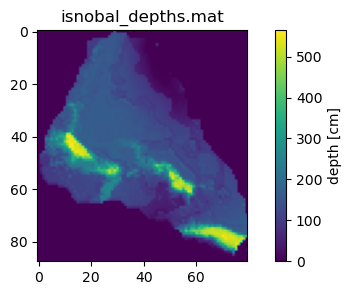

In [182]:
# for gridded data, imshow:
plt.figure(figsize=(7,3))
plt.imshow(DATA)
# plt.xticks(X.flatten())
# plt.yticks(Y.flatten())
cbar = plt.colorbar(); cbar.set_label('depth [cm]')
plt.title(fname)
plt.show()

### B: point data

In [427]:
# Remove out of bounds data
X_in = X[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
Y_in = Y[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
DATA_in = DATA[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]

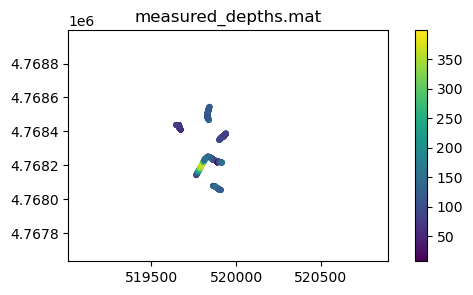

In [428]:
# for point/transect data, plot:
# list(zip(DATA, X< )
plt.figure(figsize=(7,3))
plt.scatter(X_in,Y_in,c=DATA_in.flatten(),s=10)
plt.colorbar()
plt.title(fname)
plt.gca().set_aspect('equal')
plt.xlim(519012,520895); plt.ylim(4767635,4768996)
plt.show()

# 2) Create Xm grid from the lidar data bounds/grid

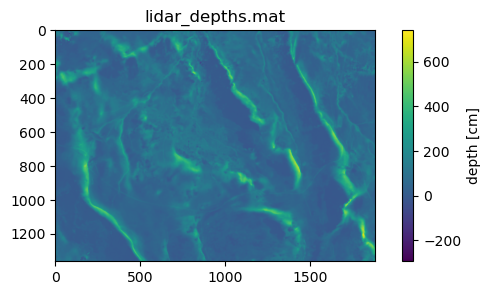

(1362, 1884)


In [178]:
# # step 1: create the 3 meter grid (center Xs and Ys) from the lidar dataset (1 m)
new_res = 3 # meter spacing for grid

[lidar_DATA, lidar_X, lidar_Y] = read_ground_data_mat(ground_data_folder+'lidar_depths.mat')
lidar_X = lidar_X.flatten()
lidar_Y = lidar_Y.flatten()

# determine where edges lie
edge_X_min = np.min(lidar_X)-0.5; edge_X_max = np.max(lidar_X)+0.5
edge_Y_top = np.max(lidar_Y)+0.5; edge_Y_bottom = np.min(lidar_Y)-0.5

grid_X = np.arange(edge_X_min+new_res/2, edge_X_max, new_res)
grid_Y = np.arange(edge_Y_top, edge_Y_bottom+new_res/2, -new_res)

plt.figure(figsize=(7,3)); plt.imshow(lidar_DATA); plt.title('lidar_depths.mat'); 
cbar = plt.colorbar(); cbar.set_label('depth [cm]'); plt.show()
print(lidar_DATA.shape)

# 3) Interpolate ground data to Xm grid

### A: Resample gridded data

In [114]:
from scipy.interpolate import interp2d

(454, 628)
Resampled to new dimensions: (454, 628)


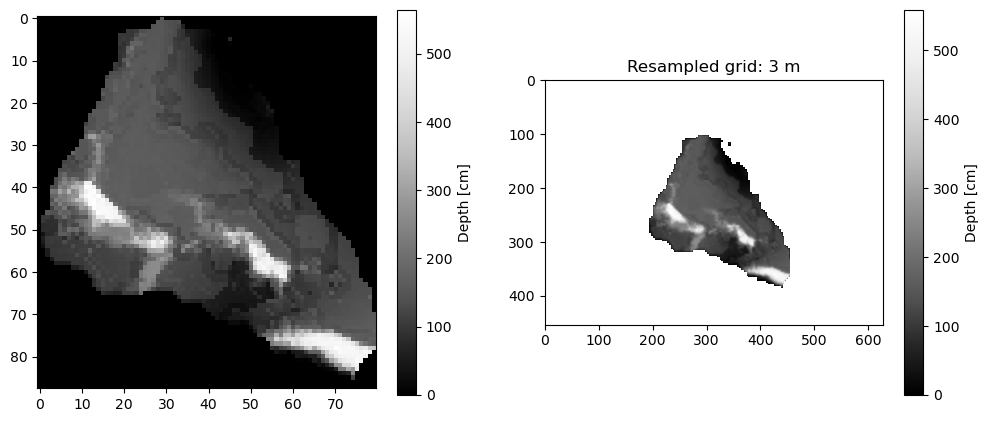

Save resampled grid to /Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ground_data/isnobal_depths_3m.tif


In [305]:
outfile = fname[:-4]+'_'+str(new_res)+'m.tif'
outpath = ground_data_folder


# Create thew new x and y grid values using DEM bounds and the chipsize
resamp = np.zeros((len(grid_Y), len(grid_X))) # create an empty resampled DEM grid
print(resamp.shape)

# Resample to your new DEM bounds
f = interp2d(X.flatten(), Y.flatten(), DATA, fill_value=np.NaN) # create DEM interpolation object
resamp = f(grid_X,grid_Y) # resample the NIR data to the DSM coordinates
resamp = np.flipud(resamp) # flip up down
resamp[resamp==0.0] = np.NaN # convert 0 depths to NaNs
print("Resampled to new dimensions:",resamp.shape)

# Display the two DEMs as a visual check
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5))
im1 = ax1.imshow(DATA, cmap='Greys_r', vmin=0)
# ax1.set_title('Original DEM: '+str(refdem.transform[0])+' m') # original spatial resolution
fig.colorbar(im1, ax=ax1,label='Depth [cm]')

im2 = ax2.imshow(resamp, cmap='Greys_r', vmin=0)
ax2.set_title('Resampled grid: '+str(new_res)+' m') # new spatial resolution
fig.colorbar(im2, ax=ax2,label='Depth [cm]')
plt.show()

# Save the resampled DEM to georeferenced tif file
print("Save resampled grid to", outpath+outfile)
with rio.open(outpath+outfile,'w',
                  driver='GTiff',
                  height=resamp.shape[0], # new shape
                  width=resamp.shape[1], # new shape
                  dtype=resamp.dtype, # data type
                  count=1,
                  crs='EPSG:32611', # the EPSG for Reynolds Mounain
                  transform=rio.Affine(new_res, 0.0, edge_X_min, # modified transform
                                       0.0, -new_res, edge_Y_top)) as dst:
        dst.write(resamp, 1)

### B: IDW spatial interpolation of point data

In [429]:
from scipy.interpolate import griddata

In [430]:
points = np.array(list(zip(X_in.flatten(), Y_in.flatten()))) # zip points
points.shape

(762, 2)

In [431]:
values = DATA_in
values = values.flatten()
values.shape

(762,)

In [432]:
mesh_x, mesh_y = np.meshgrid(grid_X, grid_Y) # meshgrid

In [433]:
interpolated_grid = griddata(points, values, (mesh_x, mesh_y), method='cubic', fill_value = np.nan)
interpolated_grid.shape

(454, 628)

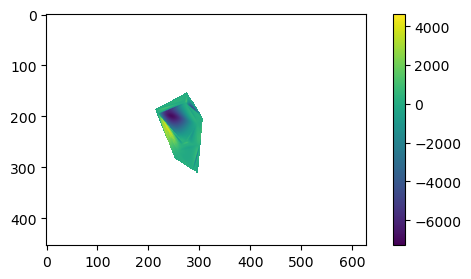

In [434]:
fig, ax = plt.subplots(figsize=(7,3))
# contour = ax.tricontourf(X.flatten(), Y.flatten(), values)
# plt.scatter(X.flatten(), Y.flatten(), marker='^',color='red')
plt.imshow(interpolated_grid)
plt.colorbar()
# plt.xlim(519012,520895); plt.ylim(4767635,4768996)
plt.show()

In [288]:
# save
outfile = fname[:-4]+'_'+str(new_res)+'m.tif'
outpath = ground_data_folder

with rio.open(outpath+outfile,'w',
                  driver='GTiff',
                  height=interpolated_grid.shape[0], # new shape
                  width=interpolated_grid.shape[1], # new shape
                  dtype=interpolated_grid.dtype, # data type
                  count=1,
                  crs='EPSG:32611', # the EPSG for Reynolds Mounain
                  transform=rio.Affine(new_res, 0.0, edge_X_min, # modified transform
                                       0.0, -new_res, edge_Y_top)) as dst:
        dst.write(interpolated_grid, 1)

In [13]:
# from sklearn.neighbors import KNeighborsRegressor

In [117]:
# # # step 1: create the 3 meter grid (center Xs and Ys) from the lidar dataset (1 m)
# new_res = 3 # meter spacing for grid
# fname = 'lidar_depths.mat'
# [lidar_DATA, lidar_X, lidar_Y] = read_ground_data_mat(ground_data_folder+fname)
# lidar_X = lidar_X.flatten()
# lidar_Y = lidar_Y.flatten()

# # determine where edges lie
# edge_X_min = np.min(lidar_X)-0.5; edge_X_max = np.max(lidar_X)+0.5
# edge_Y_top = np.max(lidar_Y)+0.5; edge_Y_bottom = np.min(lidar_Y)-0.5

# grid_X = np.arange(edge_X_min+new_res/2, edge_X_max, new_res)
# grid_Y = np.flip(np.arange(edge_Y_bottom+new_res/2, edge_Y_top, new_res))

# # # meshgrid the coordinates
# # all_Xs = np.meshgrid(grid_X, grid_Y)[0].ravel()
# # all_Ys = np.meshgrid(grid_X, grid_Y)[1].ravel()

# # # create data frame 
# # itrp = pd.DataFrame()
# # itrp['X'] = all_Xs
# # itrp['Y'] = all_Ys

In [63]:
# EXTRA STEP WITH GRIDDED DATA TO GET X, Y, DATA AS ITS OWN THING


In [64]:
# # grab a data frame with data to interpolate
# ground_data_df = pd.DataFrame(list(zip(X.flatten(), Y.flatten(), DATA.flatten())), columns=['X','Y','data'])
# ground_data_df.head()

In [65]:
# coords = ground_data_df[['X','Y']]
# values = ground_data_df['data']

In [66]:
# # predict the model is the IDW interpolation
# model = KNeighborsRegressor(algorithm='kd_tree', n_neighbors=25, weights='distance').fit(coords, values)
# pred=model.predict(itrp[['X','Y']])
# itrp['interp_data'] = pred

In [67]:
# itrp.head()

In [61]:
# plt.scatter(itrp['X'],itrp['Y'],c=itrp['interp_data'])
# plt.colorbar()
# plt.show()

# 4) Compare datasets

In [161]:
# ground data files
ground_data_folder = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ground_data/'
os.listdir(ground_data_folder)

['lidar_depths_1m.tif',
 'isnobal_SWE.mat',
 '.DS_Store',
 'lidar_depths.mat',
 'isnobal_depths_10m.tif.aux.xml',
 'lidar_depths_10m.tif',
 'measured_depths.mat',
 'lidar_depths_3m.tif.aux.xml',
 'cores_depths.mat',
 'isnobal_depths_3m.tif',
 'isnobal_depths_10m.tif',
 'cores_density.mat',
 'cores_SWE.mat',
 'isnobal_depths_1m.tif',
 'lidar_depths_3m.tif',
 'isnobal_depths.mat',
 'lidar_depths_10m.tif.aux.xml']

### A: two grids of data

In [435]:
# read in tifs and subtract and plot
fname1 = 'isnobal_depths_10m.tif'
file1 = rio.open(ground_data_folder+fname1) # open 
data1 = file1.read(1) 

fname2 = 'lidar_depths_10m.tif'
file2 = rio.open(ground_data_folder+fname2) # open
data2 = file2.read(1) # read in the first and only band (elevations)

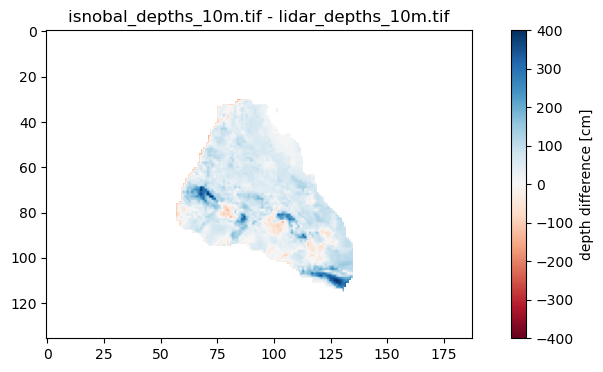

In [436]:
plt.figure(figsize=(10,4))
plt.imshow(data1-data2, cmap='RdBu',vmin=-400,vmax=400)
cbar = plt.colorbar(); cbar.set_label('depth difference [cm]')
plt.title(fname1+' - '+fname2)
plt.show()

### B: points and gridded data

In [437]:
# read in tifs and subtract and plot
fname1 = 'lidar_depths_3m.tif'
file1 = rio.open(ground_data_folder+fname1) # open 
data1 = file1.read(1) 

fname2 = 'measured_depths.mat'
[DATA, X, Y] = read_ground_data_mat(ground_data_folder+fname2)
X = X.flatten(); Y = Y.flatten(); data2 = DATA.flatten()

# Remove out of bounds data
X_in = X[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
Y_in = Y[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
DATA_in = DATA[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]

In [438]:
# find nearest idxs
x_idxs = []; y_idxs = []
for i in range(0, len(X_in)):
    x = X_in[i]; y = Y_in[i]

    x_idxs.append(np.argmin(np.abs(grid_X-x)))
    y_idxs.append(np.argmin(np.abs(grid_Y-y)))
# print(x_idxs, y_idxs)

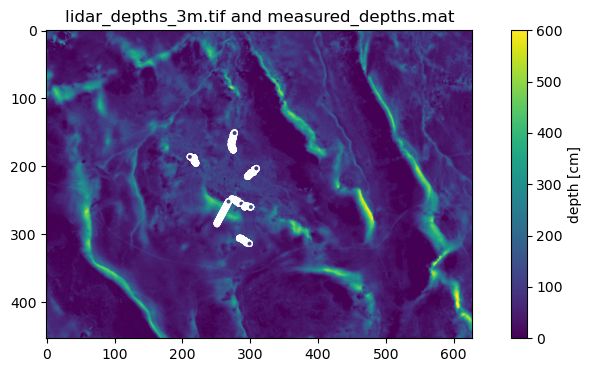

In [439]:
plt.figure(figsize=(10,4))
plt.imshow(data1,vmin=0, vmax=600)
cbar = plt.colorbar(); cbar.set_label('depth [cm]')
plt.scatter(x_idxs, y_idxs, c=DATA_in, marker='o',s=15,edgecolors='white',vmin=0, vmax=600)
plt.title(fname1+' and '+fname2)
plt.show()

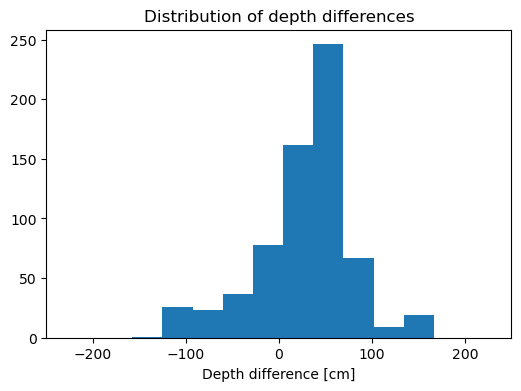

In [309]:
# grab difference in depth at points
gridded_depths_at_points = data1[y_idxs, x_idxs].flatten()
diff = gridded_depths_at_points - DATA_in.flatten()

plt.figure(figsize=(6,4))
plt.hist(diff)
plt.xlim(-250,250); plt.title('Distribution of depth differences'); plt.xlabel('Depth difference [cm]')
plt.show()

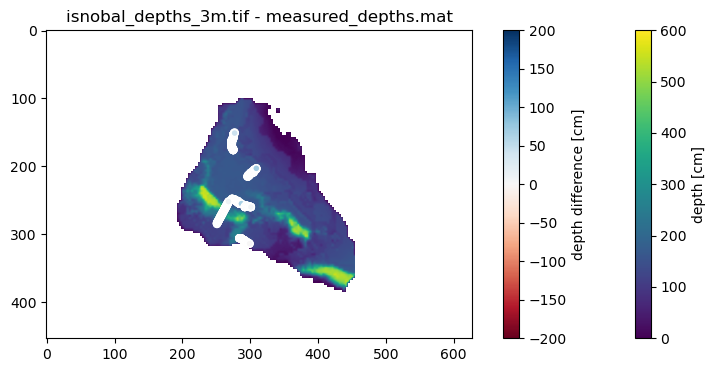

In [311]:
plt.figure(figsize=(10,4))
plt.imshow(data1,vmin=0, vmax=600)
cbar1 = plt.colorbar(); cbar1.set_label('depth [cm]')
plt.scatter(x_idxs, y_idxs, c=diff, cmap='RdBu',marker='o',s=25,edgecolors='white',vmin=-200, vmax=200)
cbar2 = plt.colorbar(); cbar2.set_label('depth difference [cm]')
plt.title(fname1+' - '+fname2)
plt.show()

# 5) Display radar data

In [354]:
radar_exports = glob.glob('/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd*1000scale*200size*1mod*.csv')
radar_exports.sort()
print(radar_exports)

['/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd10_1000scale_200size_1mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd1_1000scale_200size_1mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd2_1000scale_200size_1mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd3_1000scale_200size_1mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd4_1000scale_200size_1mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd5_1000scale_200size_1mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd6_1000scale_200size_1mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd7_1000scale_200size_1mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd8_1000scale_200size_1mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/rd9_1000scale_200size_1mod.csv']


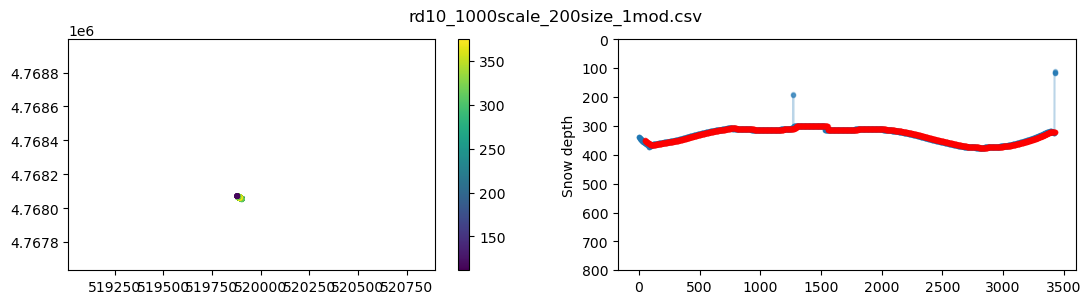

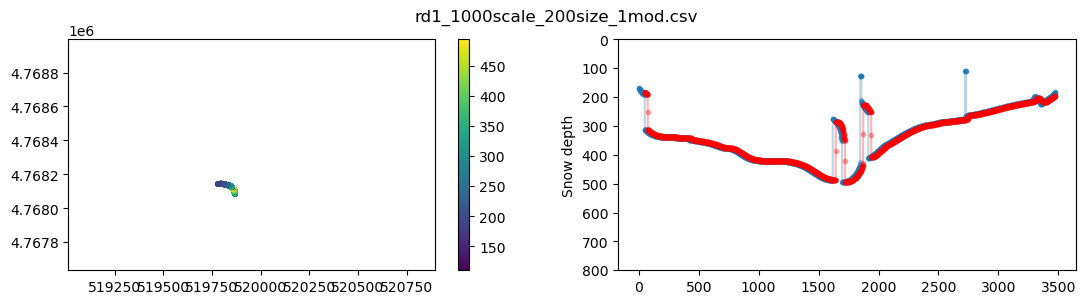

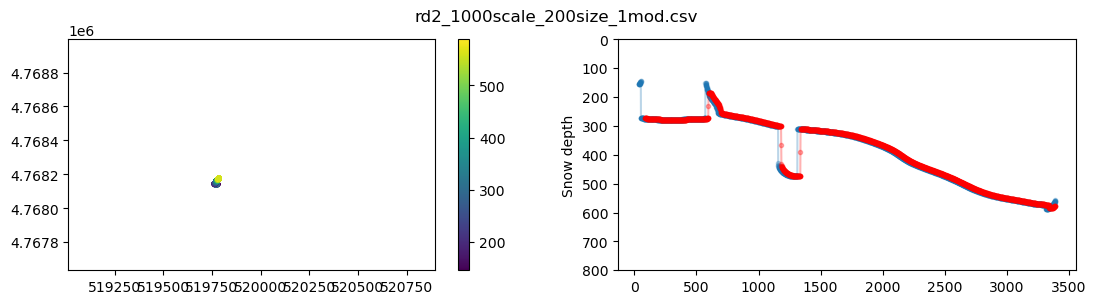

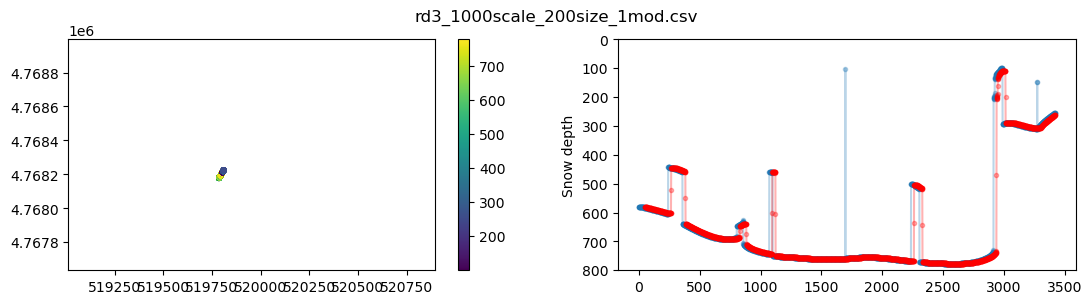

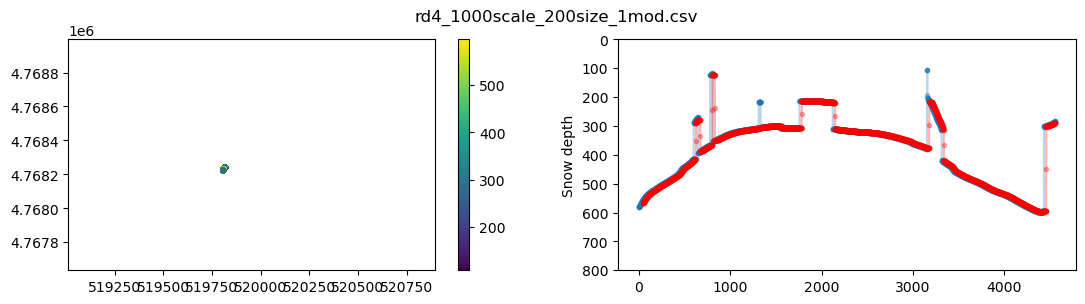

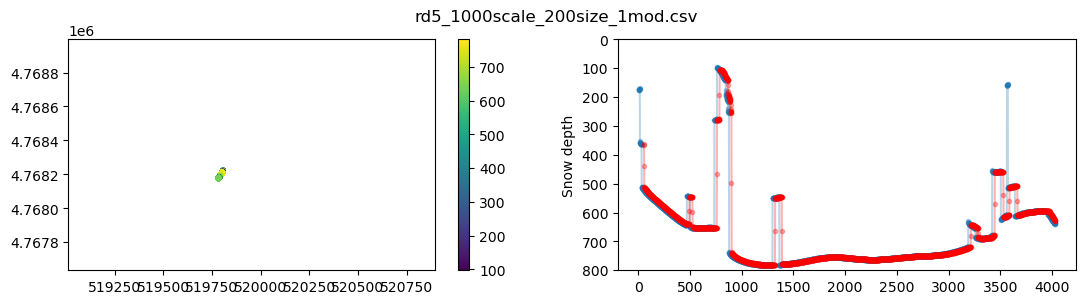

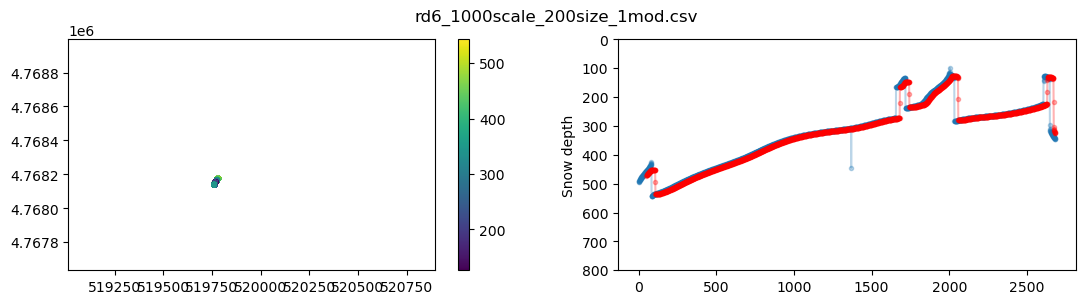

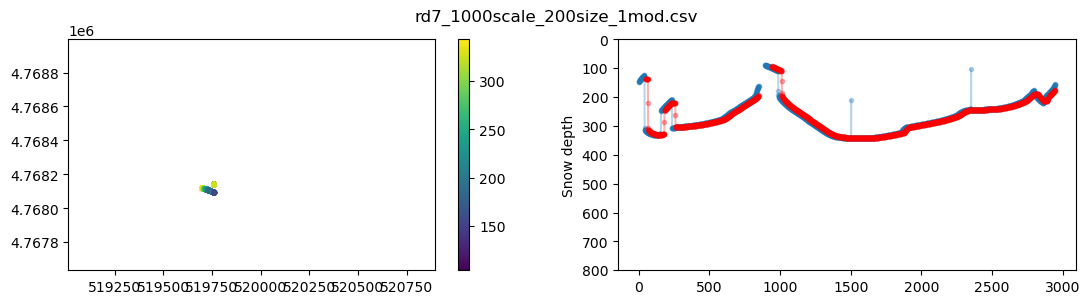

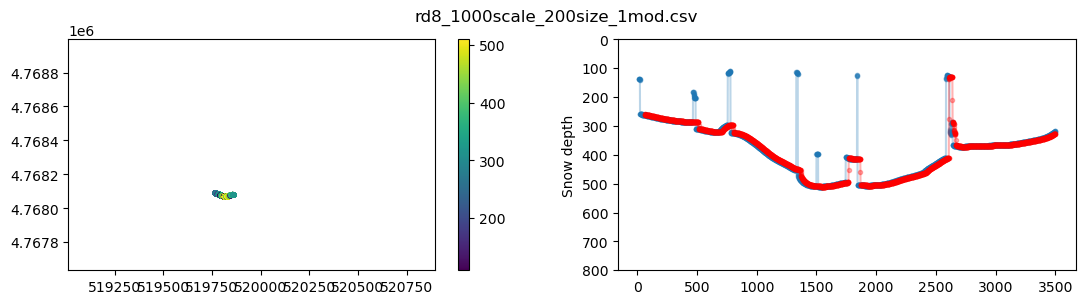

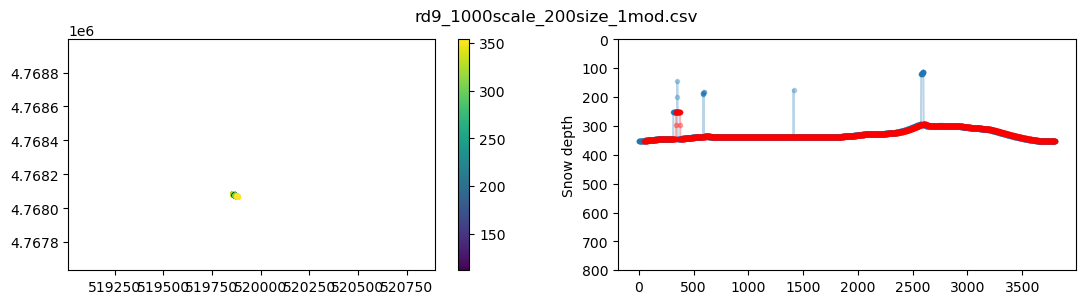

In [355]:
radar_dfs = []
for rd_file in radar_exports:
    rd_xy_df = pd.read_csv(rd_file)
    depth_df = rd_xy_df.depth # grab depths as its own df
    
    # display radar data
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(13,3))
    im1 = ax1.scatter(rd_xy_df.x,rd_xy_df.y,c=rd_xy_df.depth,s=10); 
    ax1.set_xlim(519012,520895); ax1.set_ylim(4767635,4768996);
    plt.colorbar(im1)
    
    # plot depth transect:
    ax2.plot(range(0,len(rd_xy_df.depth)), rd_xy_df.depth, '.-',alpha=0.3)
    ax2.set_ylabel('Snow depth'); ax2.set_ylim(800,0)
    plt.suptitle(rd_file.split('/')[-1])
    

    # linear interpolation and outlier removal - IMPROVE UPON ROLLING MEDIAN
    winsize = 50
    depth_interp = depth_df.rolling(window=winsize).median()
    ax2.plot(range(0,len(rd_xy_df.depth)), depth_interp,'r.-',alpha=0.3)

    # add interpolated data to rd_df
    rd_xy_df['depth_interp'] = depth_interp
    radar_dfs.append(rd_xy_df)
    plt.show()

In [409]:
# concatenate
all_radar_dfs = pd.concat(radar_dfs)
all_radar_dfs = all_radar_dfs.dropna().reset_index()
all_radar_dfs = all_radar_dfs.reset_index()
all_radar_dfs.head()


,level_0,index,Unnamed: 0,x,y,depth,depth_interp
0,0,49,49,519883.077526,4.768067e+06,358.146286,349.667931
1,1,50,50,519883.084304,4.768067e+06,358.403206,350.053310
2,2,51,51,519883.091087,4.768067e+06,358.660126,350.438690
3,3,52,52,519883.097868,4.768067e+06,358.917046,350.824070
4,4,53,53,519883.104651,4.768067e+06,359.173965,351.209450


In [400]:
# enter into grid data
points = np.array(list(zip(all_radar_dfs.x,all_radar_dfs.y))) # zip points
values = np.array(all_radar_dfs.depth_interp)

interpolated_grid = griddata(points, values, (mesh_x, mesh_y), method='linear', fill_value = np.nan)
interpolated_grid.shape

(454, 628)

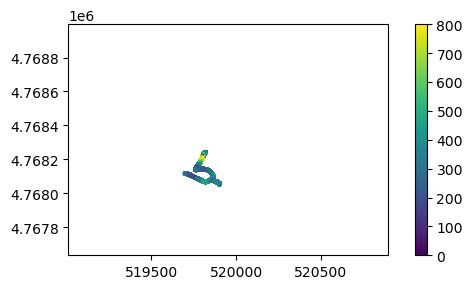

In [401]:
fig, ax = plt.subplots(figsize=(7,3))
plt.scatter(all_radar_dfs.x, all_radar_dfs.y, s=5, c=all_radar_dfs.depth_interp,vmin=0, vmax=800)
plt.colorbar();
plt.gca().set_aspect('equal')
plt.xlim(519012,520895); plt.ylim(4767635,4768996)
plt.show()

In [422]:
# fig, ax = plt.subplots(figsize=(7,3))
# # contour = ax.tricontourf(X.flatten(), Y.flatten(), values)
# # plt.scatter(X.flatten(), Y.flatten(), marker='^',color='red')
# plt.imshow(interpolated_grid, vmin=0,vmax=800)
# plt.colorbar()
# # plt.xlim(519012,520895); plt.ylim(4767635,4768996)
# plt.show()

In [423]:
# plt.imshow(interpolated_grid[250:350, 200:300], vmin=0, vmax=800)
# plt.show()

### Compare directly with lidar data

In [410]:
# subtract directly from lidar depths
x_idxs = []; y_idxs = []
for i in range(0, len(all_radar_dfs.x)):
    x = all_radar_dfs.x[i]; y = all_radar_dfs.y[i]

    x_idxs.append(np.argmin(np.abs(grid_X-x)))
    y_idxs.append(np.argmin(np.abs(grid_Y-y)))

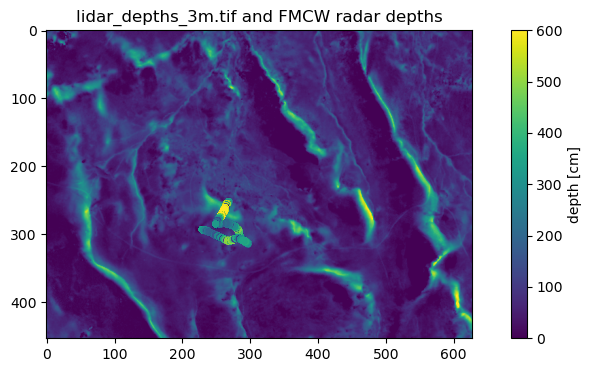

In [418]:
plt.figure(figsize=(10,4))
plt.imshow(data1,vmin=0, vmax=600)
cbar = plt.colorbar(); cbar.set_label('depth [cm]')
plt.scatter(x_idxs, y_idxs, c=all_radar_dfs.depth, marker='o',s=15,vmin=0, vmax=600)
plt.title(fname1+' and FMCW radar depths')
plt.show()

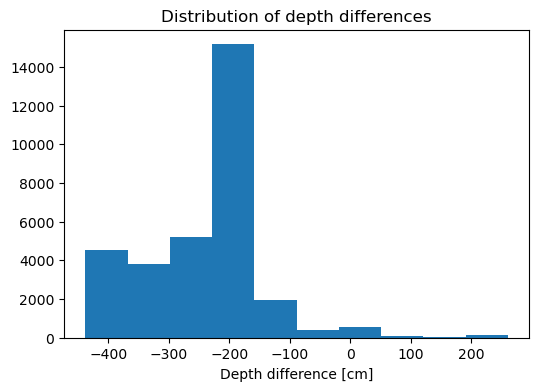

In [415]:
# grab difference in depth at points
gridded_depths_at_points = data1[y_idxs, x_idxs].flatten()
diff = gridded_depths_at_points - all_radar_dfs.depth

plt.figure(figsize=(6,4))
plt.hist(diff)
# plt.xlim(-250,250); 
plt.title('Distribution of depth differences'); plt.xlabel('Depth difference [cm]')
plt.show()

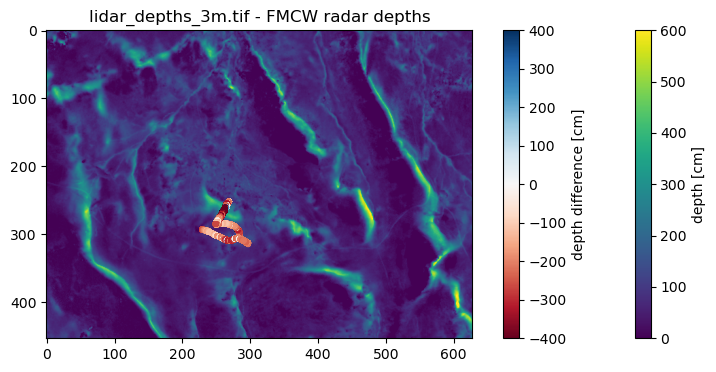

In [425]:
plt.figure(figsize=(10,4))
plt.imshow(data1,vmin=0, vmax=600)
cbar1 = plt.colorbar(); cbar1.set_label('depth [cm]')
plt.scatter(x_idxs, y_idxs, c=diff, cmap='RdBu',marker='o',s=10,vmin=-400, vmax=400)
cbar2 = plt.colorbar(); cbar2.set_label('depth difference [cm]')
plt.title(fname1+' - FMCW radar depths')
plt.show()